# This dataset contains 500,000 records of customer purchase behavior for an e-commerce platform.

# Goals: 
1. Perform EDA and Clean data
2. Predict whether a particular customer will make a purchase (purchaseStatus)
3. Cluster customers into cohorts
3. Build a PowerBI dashboard

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_excel('online_retail.xlsx')

# Check and remove null entries where applicable

In [2]:
df.dtypes


InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


- Looking at the data, we see that CustomerID and Description contains null values. I will drop entries without CustomerId's because it's required for further analysis.

- Additionally, I wll produce a total value for each transaction column and sort my data.

In [4]:
print(df.head())
print(df['CustomerID'].isnull().sum())
print(f"df shape before dropping {df.shape}")
df = df.dropna(subset=['CustomerID'])
print(f"df shape after drop {df.shape}")
df = df.sort_values("InvoiceDate")
df['Total'] = round(df["UnitPrice"] * df["Quantity"],2)

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
135080
df shape before dropping (541909, 8)
df shape after drop (406829, 8)


# Check for negative Quantity Value = returns

In [5]:
print(df['Quantity'].describe())

count    406829.000000
mean         12.061303
std         248.693370
min      -80995.000000
25%           2.000000
50%           5.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64


In [6]:
df = df[df['Quantity'] >= 0]
print(df['Quantity'].describe())

df['CustomerID'] = df['CustomerID'].astype('Int64').astype('string')

print(df['CustomerID'])

count    397924.000000
mean         13.021823
std         180.420210
min           1.000000
25%           2.000000
50%           6.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64
0         17850
1         17850
2         17850
3         17850
4         17850
          ...  
541896    12680
541895    12680
541907    12680
541900    12680
541908    12680
Name: CustomerID, Length: 397924, dtype: string


Check for most expensive and least expensive items

In [7]:
most_expensive = df.loc[df['UnitPrice'] == df['UnitPrice'].max()]
most_expensive

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total
173382,551697,POST,POSTAGE,1,2011-05-03 13:46:00,8142.75,16029,United Kingdom,8142.75


Least expensive

In [8]:
least_expensive = df.loc[df['UnitPrice'] == df['UnitPrice'].min()]
least_expensive = least_expensive.groupby(['Description', 'UnitPrice'], as_index=False)['Quantity'].agg('sum')

least_expensive

,Description,UnitPrice,Quantity
0,OVAL WALL MIRROR DIAMANTE,0.0,1
1,36 FOIL STAR CAKE CASES,0.0,144
2,ADVENT CALENDAR GINGHAM SACK,0.0,4
3,ASSTD DESIGN 3D PAPER STICKERS,0.0,12540
4,BISCUIT TIN VINTAGE CHRISTMAS,0.0,216
5,CERAMIC BOWL WITH LOVE HEART DESIGN,0.0,36
6,CHILDREN'S APRON DOLLY GIRL,0.0,1
7,CHILDS BREAKFAST SET CIRCUS PARADE,0.0,1
8,CHRISTMAS PUDDING TRINKET POT,0.0,12
9,FAIRY CAKES NOTEBOOK A6 SIZE,0.0,16


Looking at the most expensive item after returns are filtered out, we see that it's postage. On the other hand, the least expensive items are al $0, so we will have to filter out them.

In [9]:
df = df[df['UnitPrice'] > 0.00]

least_expensive = df.loc[df['UnitPrice'] == df['UnitPrice'].min()]
least_expensive = least_expensive.groupby(['Description', 'UnitPrice'], as_index=False)['Quantity'].agg('sum')

least_expensive

,Description,UnitPrice,Quantity
0,Bank Charges,0.001,1
1,PADS TO MATCH ALL CUSHIONS,0.001,3


After filtering out items that are $0.00, we see that bank charges and pads to match all cushions are 0.01. Perhaps, these are misc charges or clearence items. For this case, I will filter them out.

In [10]:
df = df[df['UnitPrice'] > 0.01]

least_expensive = df.loc[df['UnitPrice'] == df['UnitPrice'].min()]
least_expensive = least_expensive.groupby(['Description', 'UnitPrice'], as_index=False)['Quantity'].agg('sum')

least_expensive

,Description,UnitPrice,Quantity
0,POPART WOODEN PENCILS ASST,0.04,8600


Looking at the cheapest item now, we see they are pencils which is logical.

# Distribution of Quantity per month and Total spent per month

In [11]:
df["month_num"] = df["InvoiceDate"].dt.month

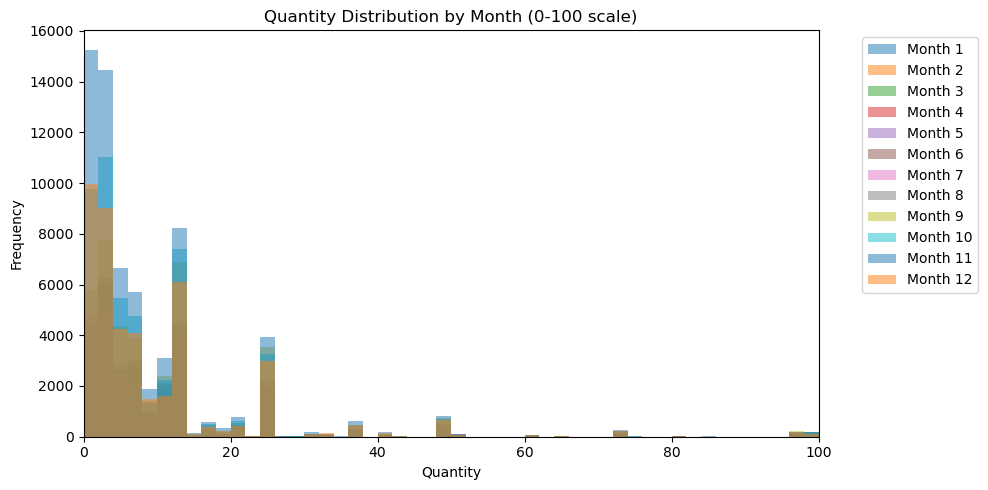

In [12]:
plt.figure(figsize=(10,5))

custom_bins = range(0, 102, 2)

for month, group_data in df.groupby("month_num"):
    plt.hist(group_data["Quantity"], alpha=0.5, label=f"Month {month}", bins=custom_bins)
    
plt.title("Quantity Distribution by Month (0-100 scale)")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.xlim(0, 100)

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [13]:
retail_customers = df.groupby(['Total', 'CustomerID'], as_index=False)['Total'].agg('sum')

top_10 = retail_customers.sort_values('Total').tail(10)
bottom_10 = retail_customers.sort_values('Total', ascending=False).tail(10)

print(top_10)
print(bottom_10)

       CustomerID     Total
136229      17511   11456.0
138840      15749   13078.8
136209      15311   13604.0
138781      18102   13740.0
138820      18102   19710.0
138573      18102   21984.0
138703      18102   26106.0
138843      15098   38970.0
138844      12346   77183.6
138845      16446  168469.6
   CustomerID  Total
19      16923   0.12
20      16931   0.12
21      17315   0.12
22      17346   0.12
23      17571   0.12
2       14104   0.10
4       15920   0.10
3       15858   0.10
1       14456   0.08
0       12748   0.06


/var/folders/nl/5h6ctj8n4v3_91b54yz2q7j80000gn/T/ipykernel_10943/3948700582.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top_10['Total'])


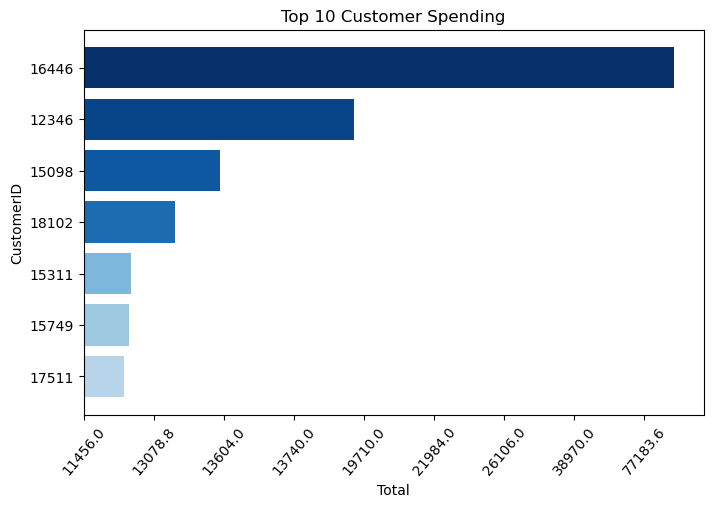

In [14]:
import matplotlib.pyplot as plt
import numpy as np
auto_colors = plt.cm.Blues(np.linspace(0.3,1,10))
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(top_10['CustomerID'], top_10['Total'], color=auto_colors)
ax.set_xticklabels(top_10['Total'])
ax.set_title('Top 10 Customer Spending')
ax.set_xlabel('Total')
ax.set_ylabel('CustomerID')
plt.xticks(rotation=50)
plt.show()

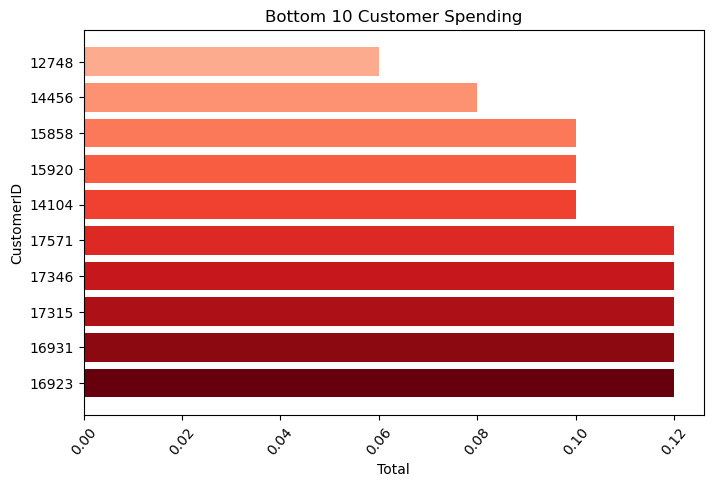

In [15]:
import matplotlib.pyplot as plt
auto_colors = plt.cm.Reds(np.linspace(1,0.3,10))
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(bottom_10['CustomerID'], bottom_10['Total'], color=auto_colors)

ax.set_title('Bottom 10 Customer Spending')
ax.set_xlabel('Total')
ax.set_ylabel('CustomerID')
plt.xticks(rotation=50)
plt.show()

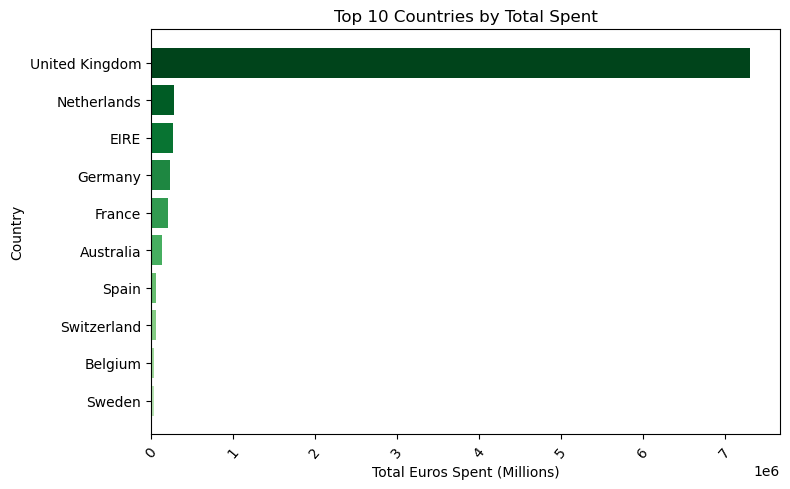

In [16]:
#group data
import numpy as np
total_countries = df.groupby('Country')['Total'].sum().sort_values(ascending=True).tail(10)
auto_colors = plt.cm.Greens(np.linspace(0.3, 1, 10))

fig, ax = plt.subplots(figsize=(8,5))
ax.barh(total_countries.index, total_countries.values, color=auto_colors)
ax.set_title('Top 10 Countries by Total Spent')
ax.set_xlabel('Total Euros Spent (Millions)')
ax.set_ylabel('Country')

plt.xticks(rotation=50)
plt.tight_layout()
plt.show()

Looking at the results, we see customer 16446 spent the most out of any customer (77183.6 euros) and customer 12748 spent the least (0.06 euros). Interestingly, majority of the money spent comes from the UK with around 7 million Euros, with no other country coming close to 1 million euros.

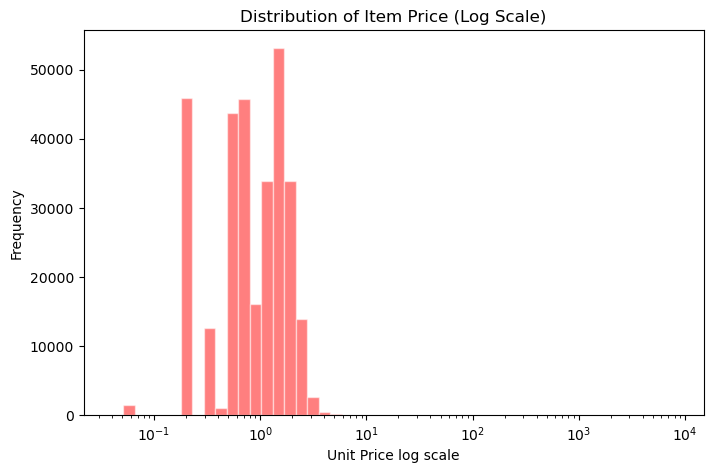

In [17]:
fig, ax = plt.subplots(figsize=(8,5))
min_price = df['UnitPrice'].min()
max_price = df['UnitPrice'].max()
log_bins = np.logspace(np.log10(min_price), np.log10(max_price), 50)
ax.hist(np.log(df['UnitPrice']), bins=log_bins, edgecolor='white', color='r', alpha=0.5)
ax.set_xscale('log')
ax.set_xlabel('Unit Price log scale')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Item Price (Log Scale)')

plt.show()

Looking a the distribution of Unit price, we have to log transform due to outliers. We see the unit prices tend to be in a similar range, with some outliers significantly affecting the distribution. 

# Categorize items into three categorizes for tiers

In [18]:
df['Price_Tier'] = pd.qcut(df['UnitPrice'], q=3, labels=['Low', 'Medium', 'High'])

print(df.groupby('Price_Tier')['UnitPrice'].agg(['min', 'max', 'count']))

             min      max   count
Price_Tier                       
Low         0.04     1.25  140715
Medium      1.27     2.95  148399
High        2.96  8142.75  108766


/var/folders/nl/5h6ctj8n4v3_91b54yz2q7j80000gn/T/ipykernel_10943/752861856.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Price_Tier')['UnitPrice'].agg(['min', 'max', 'count']))


By splitting the items into three categories: Low, Medium, High - we see that most items are below 3 euros, with a big influx ranging to 8143 euros.

# Clustering

In [ ]:
import datetime as dt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
#day after last transaction in dataset
snap = df['InvoiceDate'].max() + dt.timedelta(days=1)

#group customerid and calculate recency, frequency, monetary (RFM)
customer_df = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snap - x.max()).days, #Recency: days since last purchase
    'InvoiceNo': 'nunique', #Frequency: number of  unique orders
    'Total': 'sum', #Monetary: Total money spent
    'Quantity': 'sum' #Bonus: total items bought
}).reset_index()

#rename the columns
customer_df.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'Total': 'Monetary'
}, inplace=True)

print(customer_df.head())

  CustomerID  Recency  Frequency  Monetary  Quantity
0      12346      326          1  77183.60     74215
1      12347        2          7   4310.00      2458
2      12348       75          4   1797.24      2341
3      12349       19          1   1757.55       631
4      12350      310          1    334.40       197


In [23]:
#Log transform for skewness
log_features = np.log1p(customer_df[['Recency', 'Frequency', 'Monetary', 'Quantity']])

scaler = StandardScaler()
scaled_features = scaler.fit_transform(log_features)

# Cluster customers off RFM 

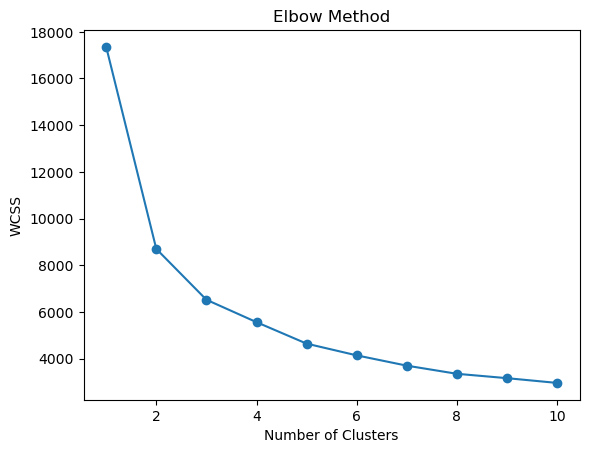

In [24]:
#Produce elbow plot to determine number of clusters
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)
    
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

Looking at the elbow plot, k = 3 seems like the best fit for the number of clusters. Choosing a different number would mix the clusters and would produce diminisioning returns.

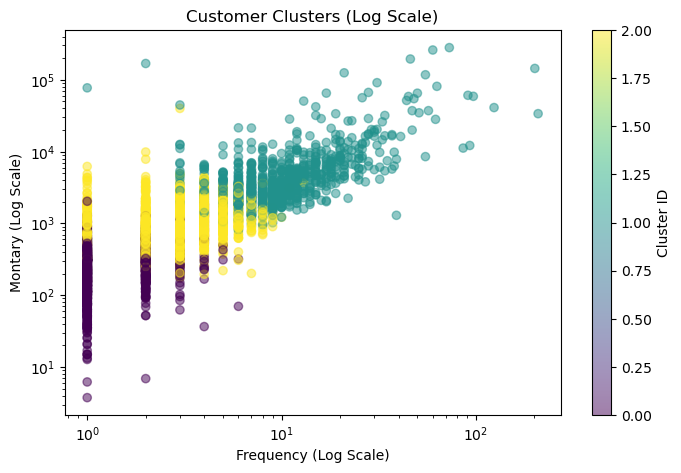

In [52]:
km = KMeans(n_clusters=3, random_state=42, n_init=10)
customer_df['Cluster'] = km.fit_predict(scaled_features)

fig, ax = plt.subplots(figsize=(8,5))
scatter = ax.scatter(customer_df['Frequency'], customer_df['Monetary'], c=customer_df['Cluster'], cmap='viridis', alpha=0.5)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Customer Clusters (Log Scale)')
ax.set_xlabel('Frequency (Log Scale)')
ax.set_ylabel('Montary (Log Scale)')
plt.colorbar(scatter, label='Cluster ID')
plt.show()

In [54]:
#Export Data for PowerBI

df.to_csv('retail_transactions_final.csv', index=False)

customer_df.to_csv('customer_segments_final.csv', index=False)
print("Data successfully exported for PowerBI")

Data successfully exported for PowerBI
